<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/medical_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Medical Insurance Dataset generated successfully!
Dataset Shape: (2000, 7)
   age     sex   bmi  children smoker     region   charges
0   56    male  28.1         3     no  southeast  20584.23
1   46  female  27.6         1     no  southwest  15315.95
2   32  female  20.4         0     no  northwest  11819.30
3   60    male  29.0         0     no  southwest  22771.50
4   25  female  36.2         3     no  southwest  18311.46


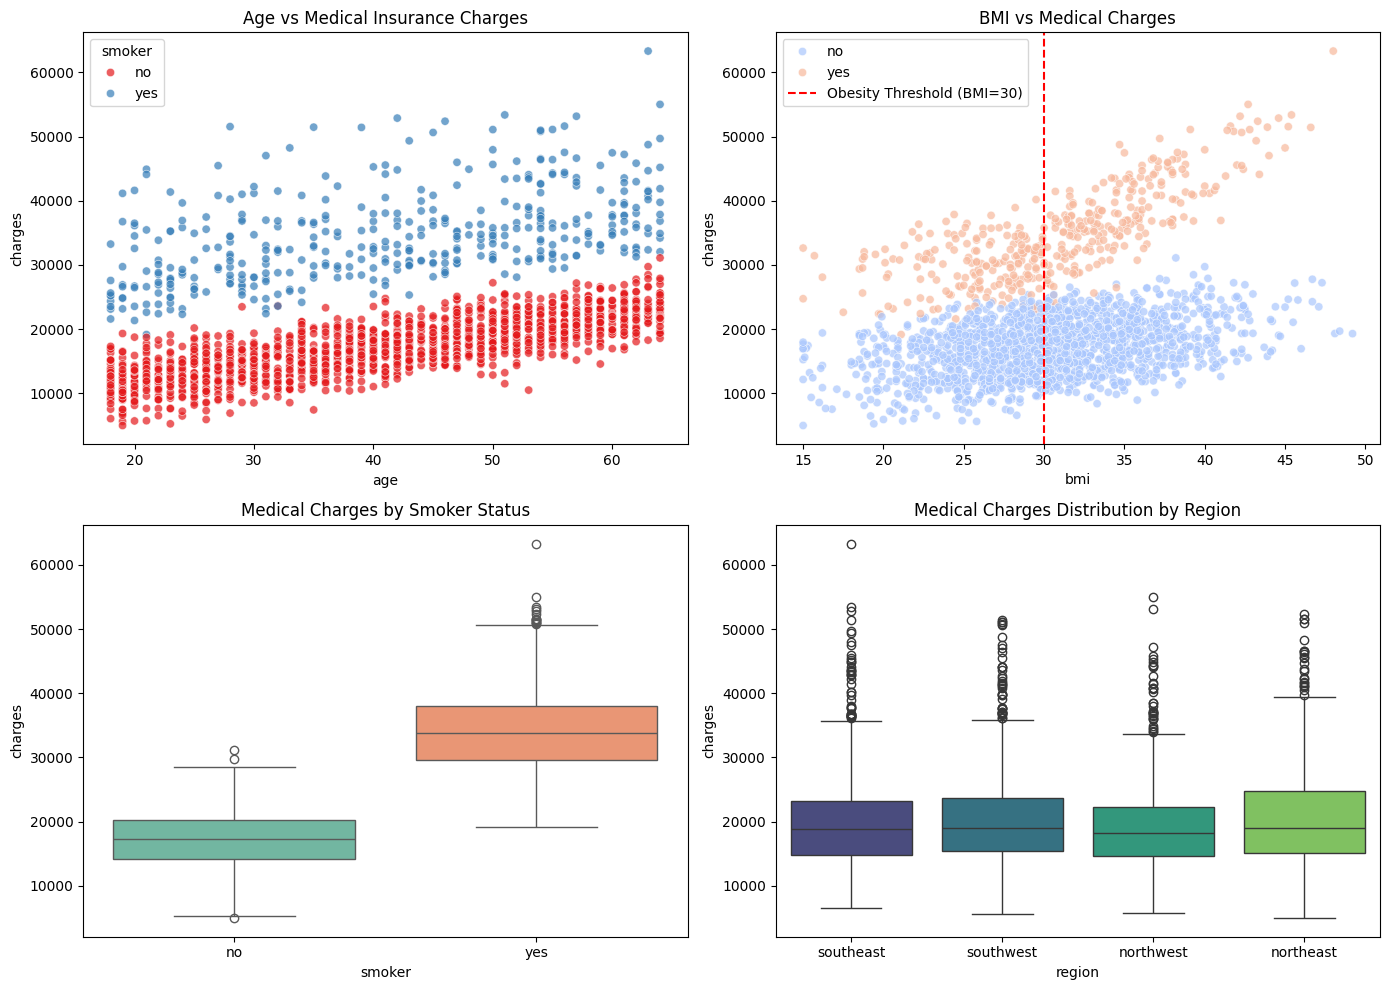

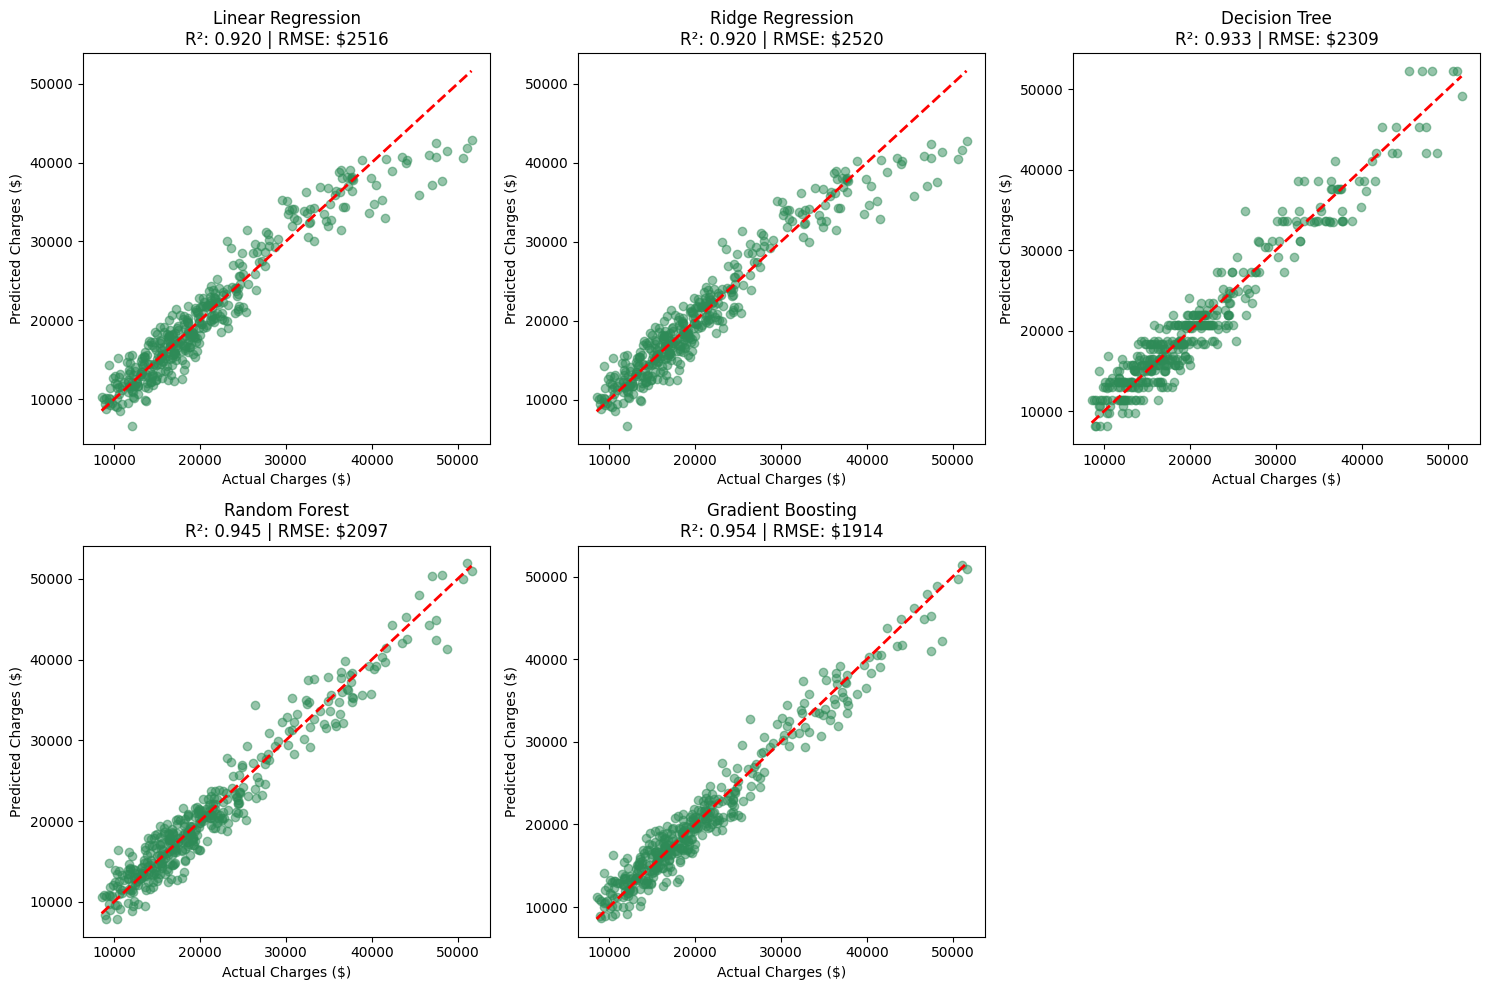

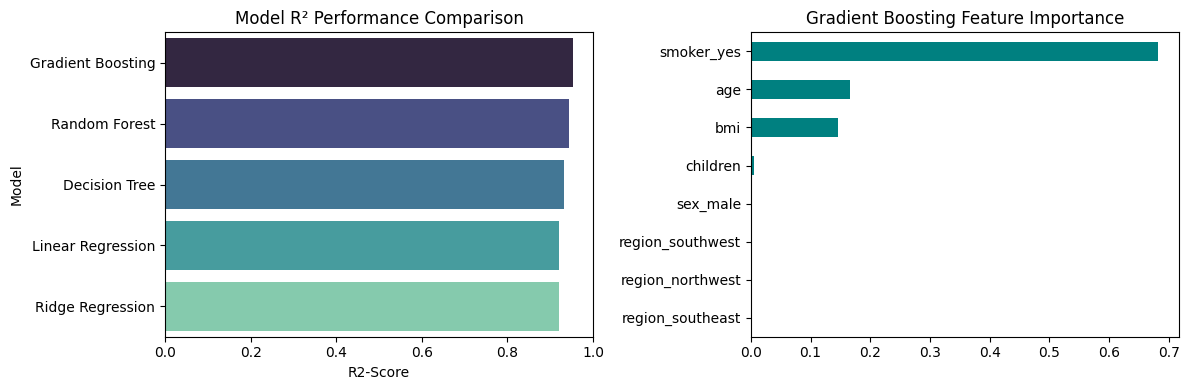


=== MEDICAL INSURANCE COST PREDICTION PERFORMANCE RANKING ===
            Model  R2-Score     MAE ($)    RMSE ($)
Gradient Boosting  0.953855 1505.994827 1913.646034
    Random Forest  0.944569 1658.229070 2097.382191
    Decision Tree  0.932814 1824.229745 2309.084169
Linear Regression  0.920261 1853.406672 2515.559496
 Ridge Regression  0.919974 1848.886089 2520.085923


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. GENERATE REALISTIC MEDICAL INSURANCE DATASET
# ==========================================
np.random.seed(42)
n_samples = 2000

# Feature Generation
age = np.random.randint(18, 65, n_samples)
sex = np.random.choice(['female', 'male'], size=n_samples, p=[0.5, 0.5])
bmi = np.random.normal(30.6, 6.0, n_samples).clip(15.0, 53.0).round(1)
children = np.random.choice([0, 1, 2, 3, 4, 5], size=n_samples, p=[0.42, 0.23, 0.18, 0.11, 0.04, 0.02])
smoker = np.random.choice(['yes', 'no'], size=n_samples, p=[0.20, 0.80])
region = np.random.choice(['southwest', 'southeast', 'northwest', 'northeast'], size=n_samples)

# Insurance Charges target ($ USD) with non-linear smoker & BMI interactions
is_smoker = (smoker == 'yes').astype(int)
bmi_obese = np.maximum(0, bmi - 30)

charges = (
    2500.0
    + 260.0 * age
    + 320.0 * (bmi - 20).clip(0, None)
    + 14000.0 * is_smoker
    + 1100.0 * is_smoker * bmi_obese  # Key interaction: smoking + obesity dramatically increases costs
    + 500.0 * children
    + np.random.normal(0, 1800, n_samples)
).clip(1000.0, 65000.0).round(2)

df = pd.DataFrame({
    'age': age,
    'sex': sex,
    'bmi': bmi,
    'children': children,
    'smoker': smoker,
    'region': region,
    'charges': charges
})

print("Medical Insurance Dataset generated successfully!")
print(f"Dataset Shape: {df.shape}")
print(df.head())


# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: Age vs Medical Charges by Smoker Status
plt.subplot(2, 2, 1)
sns.scatterplot(x="age", y="charges", data=df, hue="smoker", palette="Set1", alpha=0.7)
plt.title("Age vs Medical Insurance Charges")

# Graph 2: BMI vs Charges (Highlighting Obesity Threshold)
plt.subplot(2, 2, 2)
sns.scatterplot(x="bmi", y="charges", data=df, hue="smoker", palette="coolwarm", alpha=0.7)
plt.axvline(30, color='red', linestyle='--', label='Obesity Threshold (BMI=30)')
plt.title("BMI vs Medical Charges")
plt.legend()

# Graph 3: Distribution of Charges by Smoker Status
plt.subplot(2, 2, 3)
sns.boxplot(x="smoker", y="charges", data=df, hue="smoker", palette="Set2", legend=False)
plt.title("Medical Charges by Smoker Status")

# Graph 4: Regional Cost Comparison
plt.subplot(2, 2, 4)
sns.boxplot(x="region", y="charges", data=df, hue="region", palette="viridis", legend=False)
plt.title("Medical Charges Distribution by Region")

plt.tight_layout()
plt.show()


# ==========================================
# 3. PREPROCESSING & FEATURE ENCODING
# ==========================================
X = df.drop(columns=["charges"])
y = df["charges"]

# One-hot encode categorical variables ('sex', 'smoker', 'region')
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ==========================================
# 4. MODEL TRAINING & REGRESSION EVALUATION
# ==========================================
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0),
    "Decision Tree": DecisionTreeRegressor(random_state=42, max_depth=6),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append({
        "Model": name,
        "R2-Score": r2,
        "MAE ($)": mae,
        "RMSE ($)": rmse
    })

    # Plot Actual vs Predicted Insurance Charges
    axes[idx].scatter(y_test, y_pred, alpha=0.5, color='seagreen')
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[idx].set_title(f"{name}\nR²: {r2:.3f} | RMSE: ${rmse:.0f}")
    axes[idx].set_xlabel("Actual Charges ($)")
    axes[idx].set_ylabel("Predicted Charges ($)")

axes[5].axis("off")
plt.tight_layout()
plt.show()


# ==========================================
# 5. MODEL RANKING & FEATURE IMPORTANCE
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="R2-Score", ascending=False)

plt.figure(figsize=(12, 4))

# Chart 1: R2-Score Comparison
plt.subplot(1, 2, 1)
sns.barplot(x="R2-Score", y="Model", data=results_df, hue="Model", palette="mako", legend=False)
plt.title("Model R² Performance Comparison")
plt.xlim(0, 1)

# Chart 2: Feature Importance from Gradient Boosting
gb_model = models["Gradient Boosting"]
importances = pd.Series(gb_model.feature_importances_, index=X_encoded.columns).sort_values(ascending=True)

plt.subplot(1, 2, 2)
importances.plot(kind="barh", color="teal")
plt.title("Gradient Boosting Feature Importance")

plt.tight_layout()
plt.show()

print("\n=== MEDICAL INSURANCE COST PREDICTION PERFORMANCE RANKING ===")
print(results_df.to_string(index=False))
